# 01 — Exploratory Data Analysis, Dataset Validation & Preprocessing

## Number Plate Detection of Vehicles

This notebook performs the complete **pre-training dataset analysis** for the Number Plate Detection project.

The objective is to verify that the dataset is structurally valid, understand the characteristics of the number-plate annotations, identify image-quality limitations, demonstrate preprocessing and augmentation techniques, and determine whether the dataset is ready for YOLO training.

### Project requirements covered

1. Dataset Composition
2. Bounding Box Distribution
3. Image Quality Analysis
4. Lighting Conditions & Environmental Variability
5. Class Frequency Distribution
6. Dataset Refinement / Poor-quality Image Review
7. Image Resizing and Normalization
8. Image Preprocessing
   - Grayscale
   - Bilateral Filtering
   - Canny Edge Detection
9. Data Augmentation
   - Rotation
   - Brightness variation
   - Noise
   - Flipping
   - Cropping / scaling
10. Augmentation-effect methodology
11. Final dataset-readiness decision

> The notebook reports only evidence actually available in the dataset. Weather, regional plate style or augmentation-performance improvements are not fabricated when reliable metadata or controlled experiments are unavailable.

### Notebook presentation note

All narrative findings and plot interpretations are written as **separate Markdown cells** rather than generated from Python code. This keeps the notebook easy to edit for submission or presentation without requiring the analysis cells to be rerun.

Code cells are reserved for data loading, validation, calculations, visualizations, and file export.

Install packages

In [1]:
%pip install -q numpy pandas matplotlib opencv-python pillow pyyaml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports and project paths

In [2]:
from pathlib import Path
from collections import Counter
from IPython.display import display, Markdown

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import hashlib
import json


# --------------------------------------------------
# PROJECT LOCATION
# --------------------------------------------------

PROJECT_DIR = (
    Path.cwd().resolve().parent
    if Path.cwd().name.lower() == "notebooks"
    else Path.cwd().resolve()
)

DATA_DIR = PROJECT_DIR / "data" / "processed"
REPORT_DIR = PROJECT_DIR / "reports" / "eda_final"

REPORT_DIR.mkdir(parents=True, exist_ok=True)


print("Project directory :", PROJECT_DIR)
print("Dataset directory :", DATA_DIR)
print("EDA report folder :", REPORT_DIR)


assert DATA_DIR.exists(), (
    f"Processed dataset not found:\n{DATA_DIR}"
)

Project directory : C:\Users\david\OneDrive\Desktop\MT48-DS-David\GUVI DS Projects\Number-Plate-Detection-Final
Dataset directory : C:\Users\david\OneDrive\Desktop\MT48-DS-David\GUVI DS Projects\Number-Plate-Detection-Final\data\processed
EDA report folder : C:\Users\david\OneDrive\Desktop\MT48-DS-David\GUVI DS Projects\Number-Plate-Detection-Final\reports\eda_final


## 0. Dataset Provenance and Frozen Dataset Policy

The dataset analysed in this notebook is the **final frozen processed dataset** used by the downstream training and evaluation workflow.

### Historical preparation stage

An earlier preparation notebook, `01_eda_dataset_clean.ipynb`, was used during dataset development to:

- read the original project-provided YOLO dataset;
- verify image/label pairing;
- inspect plate counts and bounding-box size characteristics;
- group images by **plate-count complexity** and **minimum plate area**;
- create a reproducible train/validation/test assignment using `RANDOM_SEED = 42`;
- copy images and labels into a model-ready dataset structure;
- create a YOLO dataset configuration and split manifest.

That historical notebook recorded an **intermediate automated split of 92 train / 12 validation / 11 test images**.

### `Canonical final dataset`

The project was subsequently finalized using the processed dataset currently stored under `data/processed/`.  
This is the **canonical frozen split used for the final EDA, YOLO training, validation-based threshold selection, OCR work, and untouched test evaluation**:

| Split | Images | Bounding Boxes |
|---|---:|---:|
| Train | 90 | 185 |
| Validation | 13 | 23 |
| Test | 12 | 25 |
| **Total** | **115** | **233** |

The historical split-building code is **not rerun inside this final notebook**, because recreating or changing the split after model development could compromise reproducibility and test-set independence.

Instead, this notebook verifies that the expected frozen dataset is present before performing the final EDA.

In [ ]:
# --------------------------------------------------
# VERIFY THE CANONICAL FROZEN DATASET
# --------------------------------------------------

EXPECTED_IMAGES = {
    "train": 90,
    "val": 13,
    "test": 12,
}

EXPECTED_BOXES = {
    "train": 185,
    "val": 23,
    "test": 25,
}

_FROZEN_IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
}

frozen_dataset_rows = []

for split in ["train", "val", "test"]:

    image_dir = DATA_DIR / split / "images"
    label_dir = DATA_DIR / split / "labels"

    assert image_dir.exists(), f"Missing image directory: {image_dir}"
    assert label_dir.exists(), f"Missing label directory: {label_dir}"

    image_files = sorted(
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in _FROZEN_IMAGE_EXTS
    )

    label_files = sorted(label_dir.glob("*.txt"))

    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}

    assert image_stems == label_stems, (
        f"{split}: image/label mismatch detected. "
        f"Images without labels={len(image_stems - label_stems)}, "
        f"labels without images={len(label_stems - image_stems)}"
    )

    box_count = 0

    for label_path in label_files:
        lines = [
            line.strip()
            for line in label_path.read_text(
                encoding="utf-8"
            ).splitlines()
            if line.strip()
        ]
        box_count += len(lines)

    frozen_dataset_rows.append({
        "split": split,
        "images": len(image_files),
        "expected_images": EXPECTED_IMAGES[split],
        "boxes": box_count,
        "expected_boxes": EXPECTED_BOXES[split],
    })


frozen_dataset_check = pd.DataFrame(frozen_dataset_rows)

display(frozen_dataset_check)

assert (
    frozen_dataset_check["images"]
    == frozen_dataset_check["expected_images"]
).all(), "Frozen image counts do not match the expected final split."

assert (
    frozen_dataset_check["boxes"]
    == frozen_dataset_check["expected_boxes"]
).all(), "Frozen bounding-box counts do not match the expected final dataset."

print(
    "Frozen dataset verified successfully: "
    "115 images / 233 number-plate boxes."
)


## 1. Dataset Preparation and Refinement History

The dataset used in this notebook represents the **canonical frozen processed dataset** used for final model development and evaluation. Historical split-building logic is documented in Section 0 and is not rerun here.

The project workflow is:

**Data Collection → Annotation Validation → Dataset Cleaning → Frozen Train/Validation/Test Split → EDA → YOLO Training**

The source images contain vehicles with YOLO-format number-plate bounding-box annotations.

Before training, the dataset is checked for:

- missing image/label pairs;
- malformed YOLO labels;
- corrupted images;
- very low-resolution images;
- unusually dark or overexposed images;
- low-sharpness / blurred images;
- extremely small number-plate bounding boxes.

Poor-quality samples are **flagged for review rather than automatically deleted**.

A difficult image may still be valuable for object-detection robustness when the number plate can be localized and the annotation remains correct.

Therefore, EDA determines whether an image should be:

- **RETAINED**
- **REVIEWED**
- or, only when clearly unusable, **EXCLUDED**

The current project retains the frozen dataset unless a sample fails structural or annotation validation.

## 2. Dataset Composition

### Result

The processed dataset contains **115 images**:

- **Training:** 90 images (**78.3%**)
- **Validation:** 13 images (**11.3%**)
- **Test:** 12 images (**10.4%**)

All **115 images have matching YOLO label files**, with **0 images missing labels** and **0 labels missing images**.

### Evaluation interpretation

The resulting split is close to the intended **80/10/10** design while preserving independent validation and test sets. This means the final test set remains separate from training and model selection.

Because this is a **single-class detection dataset**, class balance is not assessed in the conventional multi-class sense. Instead, the notebook evaluates the number of plate annotations and the number of plates present per image.


### 2.1 Dataset Composition Audit


In [3]:
IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
}

SPLITS = ["train", "val", "test"]

composition_rows = []
image_records = []

for split in SPLITS:

    image_dir = DATA_DIR / split / "images"
    label_dir = DATA_DIR / split / "labels"

    assert image_dir.exists(), f"Missing: {image_dir}"
    assert label_dir.exists(), f"Missing: {label_dir}"

    images = sorted([
        p for p in image_dir.iterdir()
        if p.suffix.lower() in IMAGE_EXTS
    ])

    labels = sorted(label_dir.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    composition_rows.append({
        "split": split,
        "images": len(images),
        "label_files": len(labels),
        "images_without_labels":
            len(image_stems - label_stems),
        "labels_without_images":
            len(label_stems - image_stems)
    })

    for image in images:

        image_records.append({
            "split": split,
            "image_path": image,
            "stem": image.stem
        })


composition = pd.DataFrame(composition_rows)

composition["split_pct"] = (
    composition["images"]
    / composition["images"].sum()
    * 100
)

display(composition)


TOTAL_IMAGES = int(composition["images"].sum())

MISSING_IMAGE_LABELS = int(
    composition["images_without_labels"].sum()
)

ORPHAN_LABELS = int(
    composition["labels_without_images"].sum()
)


assert TOTAL_IMAGES > 0
assert MISSING_IMAGE_LABELS == 0
assert ORPHAN_LABELS == 0


print("Total images:", TOTAL_IMAGES)

,split,images,label_files,images_without_labels,labels_without_images,split_pct
0,train,90,90,0,0,78.260870
1,val,13,13,0,0,11.304348
2,test,12,12,0,0,10.434783


Total images: 115


### 2.2 Dataset Composition Visualization


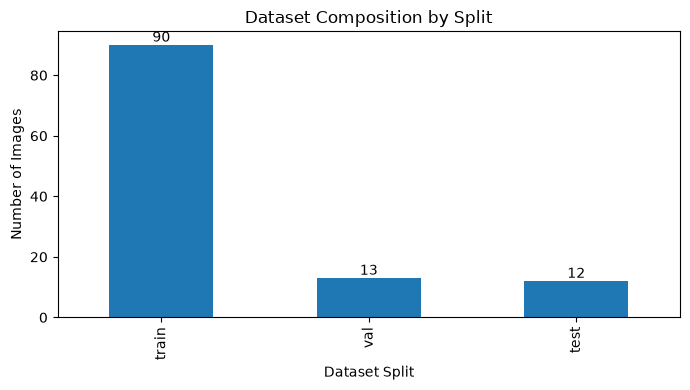

In [4]:
ax = (
    composition
    .set_index("split")["images"]
    .plot(
        kind="bar",
        figsize=(7, 4)
    )
)

ax.set_title(
    "Dataset Composition by Split"
)

ax.set_xlabel(
    "Dataset Split"
)

ax.set_ylabel(
    "Number of Images"
)

ax.bar_label(
    ax.containers[0]
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "01_dataset_split.png",
    dpi=160
)

plt.show()

### Plot Interpretation — Dataset Composition

The bar chart makes the split imbalance intentional and easy to verify: the large majority of images are used for training, while validation and test remain much smaller and independent.

This is appropriate for a small dataset because it maximizes training examples without removing the separate hold-out sets needed for validation and final testing.

### 2.3 Dataset Split Interpretation

The split-composition plot shows that most images are assigned to training, with smaller independent validation and test subsets.

- Training: **90 images**
- Validation: **13 images**
- Test: **12 images**

The distribution is close to an 80/10/10 design. The important methodological point is that validation and test remain separate: validation is used for development decisions, while test is reserved for final evaluation.

In [ ]:
train_n = int(
    composition
    .set_index("split")
    .loc["train", "images"]
)

val_n = int(
    composition
    .set_index("split")
    .loc["val", "images"]
)

test_n = int(
    composition
    .set_index("split")
    .loc["test", "images"]
)

train_pct = (
    train_n / TOTAL_IMAGES * 100
)

val_pct = (
    val_n / TOTAL_IMAGES * 100
)

test_pct = (
    test_n / TOTAL_IMAGES * 100
)


### Dataset Composition Result

The final processed dataset contains **115 vehicle images**.

- **Training:** 90 images (**78.3%**)
- **Validation:** 13 images (**11.3%**)
- **Test:** 12 images (**10.4%**)
- **Images without labels:** 0
- **Labels without matching images:** 0

All image/label pairs are therefore correctly matched.

The split is close to the intended **80/10/10** design while maintaining separate validation and test sets.

**Interpretation:**  
The training split contains enough data for model fitting, while validation remains separate for model/threshold decisions and the test split remains independent for final evaluation.

## 3. YOLO Annotation and Bounding-Box Analysis

This section validates YOLO annotations and analyses plate localization characteristics before training.


In [6]:
box_rows = []
invalid_rows = []

for rec in image_records:

    split = rec["split"]

    image_path = rec["image_path"]

    label_path = (
        DATA_DIR
        / split
        / "labels"
        / f"{rec['stem']}.txt"
    )

    lines = [
        line.strip()
        for line
        in label_path
        .read_text(
            encoding="utf-8"
        )
        .splitlines()
        if line.strip()
    ]

    for line_number, line in enumerate(
        lines,
        start=1
    ):

        values = line.split()

        if len(values) != 5:

            invalid_rows.append({
                "split": split,
                "file": label_path.name,
                "line": line_number,
                "issue":
                    "Expected 5 YOLO values"
            })

            continue

        try:

            cls, xc, yc, w, h = map(
                float,
                values
            )

        except ValueError:

            invalid_rows.append({
                "split": split,
                "file": label_path.name,
                "line": line_number,
                "issue":
                    "Non-numeric label value"
            })

            continue


        valid = (
            cls >= 0
            and float(cls).is_integer()
            and 0 <= xc <= 1
            and 0 <= yc <= 1
            and 0 < w <= 1
            and 0 < h <= 1
        )


        if not valid:

            invalid_rows.append({
                "split": split,
                "file": label_path.name,
                "line": line_number,
                "issue":
                    "Out-of-range YOLO value"
            })


        box_rows.append({
            "split": split,
            "image": image_path.name,
            "class_id": int(cls),
            "x_center": xc,
            "y_center": yc,
            "box_width": w,
            "box_height": h,
            "box_area": w * h,
            "aspect_ratio":
                w / h if h > 0 else np.nan
        })


boxes = pd.DataFrame(box_rows)

invalid = pd.DataFrame(
    invalid_rows
)

TOTAL_BOXES = len(boxes)
INVALID_BOXES = len(invalid)


print(
    "Total number-plate boxes:",
    TOTAL_BOXES
)

print(
    "Invalid annotation rows:",
    INVALID_BOXES
)

print(
    "Classes:",
    sorted(
        boxes["class_id"]
        .unique()
        .tolist()
    )
)


display(
    boxes[
        [
            "box_width",
            "box_height",
            "box_area",
            "aspect_ratio"
        ]
    ]
    .describe()
    .T
)

Total number-plate boxes: 233
Invalid annotation rows: 0
Classes: [0]


,count,mean,std,min,25%,50%,75%,max
box_width,233.0,0.098023,0.076048,0.006333,0.036000,0.082667,0.139000,0.485333
box_height,233.0,0.049939,0.039940,0.003000,0.017000,0.039250,0.074000,0.204500
box_area,233.0,0.007248,0.010651,0.000022,0.000650,0.003617,0.009867,0.099251
aspect_ratio,233.0,2.287232,1.056498,0.772815,1.507235,2.044700,2.772867,6.533400


### Bounding Box Analysis

The dataset contains **233 annotated number-plate bounding boxes**.

- **Average box width:** `0.098` (~9.8% of image width)
- **Average box height:** `0.050` (~5.0% of image height)
- **Average box area:** `0.00725` (~0.72% of total image area)
- **Average aspect ratio:** `2.29`
- **Median aspect ratio:** `2.04`
- **Aspect ratio range:** `0.77 – 6.53`

### Key Observations

1. Number plates occupy a **small portion of the overall image**, with an average bounding-box area of only about **0.72%**.
2. This indicates that license-plate detection is largely a **small-object detection problem**.
3. The average aspect ratio of **2.29** shows that most number plates are **wider than they are tall**, which is expected for license plates.
4. The variation in aspect ratio (`0.77 – 6.53`) suggests differences in **plate format, viewing angle, orientation, and perspective** across the dataset.
5. The variation in bounding-box size indicates that vehicles/plates appear at **different distances from the camera**.

**Conclusion:**  
The dataset contains relatively small license-plate objects with varying sizes and aspect ratios. These characteristics make accurate localization challenging and should be considered during YOLO model training and evaluation.

### 3.1 Bounding-Box Distributions


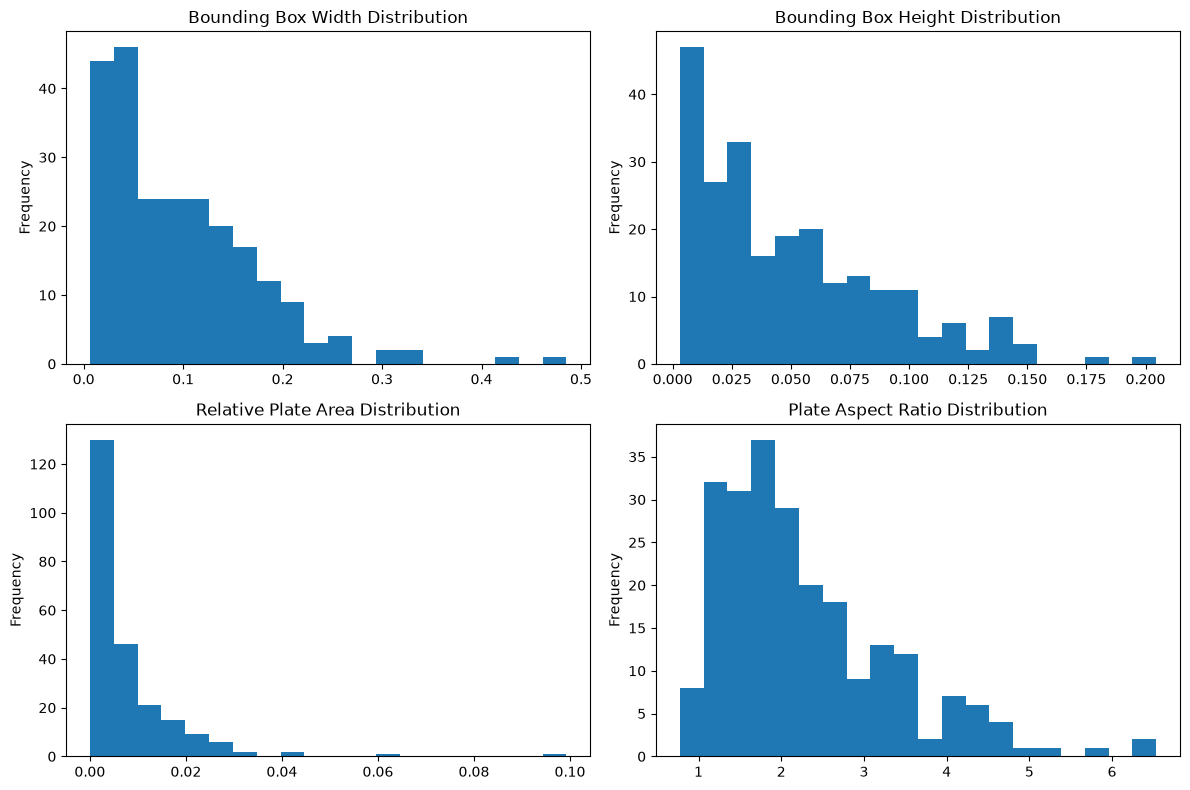

In [7]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)


axes[0, 0].hist(
    boxes["box_width"],
    bins=20
)

axes[0, 0].set_title(
    "Bounding Box Width Distribution"
)


axes[0, 1].hist(
    boxes["box_height"],
    bins=20
)

axes[0, 1].set_title(
    "Bounding Box Height Distribution"
)


axes[1, 0].hist(
    boxes["box_area"],
    bins=20
)

axes[1, 0].set_title(
    "Relative Plate Area Distribution"
)


axes[1, 1].hist(
    boxes["aspect_ratio"],
    bins=20
)

axes[1, 1].set_title(
    "Plate Aspect Ratio Distribution"
)


for ax in axes.flat:

    ax.set_ylabel(
        "Frequency"
    )


plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "02_bbox_distributions.png",
    dpi=160
)

plt.show()

### Plot Interpretation — Bounding-Box Distributions

The four histograms show that most plate boxes are concentrated toward the **smaller end** of the width, height, and area distributions.

The median plate area is only about **0.36% of the image area**, while the mean is higher at about **0.72%**, indicating a right-skewed distribution with a smaller number of relatively large plates.

The aspect-ratio distribution is centered around wider-than-tall boxes, with a median of about **2.04** and a mean of **2.29**. The long spread reflects differences in viewpoint, plate geometry, and annotation scale.

**Key takeaway:** the detector must cope with substantial variation in object scale and plate shape, especially very small plates.

### 3.2 Plates per Image


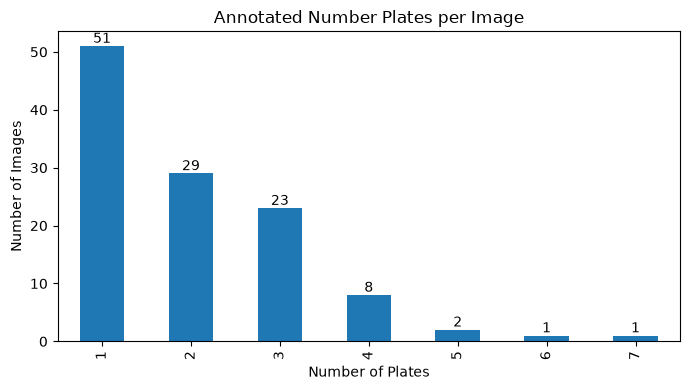

In [8]:
plate_counts = (
    boxes
    .groupby(
        ["split", "image"]
    )
    .size()
    .rename("plate_count")
    .reset_index()
)


ax = (
    plate_counts[
        "plate_count"
    ]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        figsize=(7, 4)
    )
)

ax.set_title(
    "Annotated Number Plates per Image"
)

ax.set_xlabel(
    "Number of Plates"
)

ax.set_ylabel(
    "Number of Images"
)

ax.bar_label(
    ax.containers[0]
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "03_plates_per_image.png",
    dpi=160
)

plt.show()

### 3.3 Plates-per-Image Interpretation

The plates-per-image plot shows that the dataset is not limited to one vehicle or one plate per image. Some scenes contain several annotated plates, with a maximum of **7 plates in a single image**.

Across the full dataset there are **233 plates in 115 images**, or about **2.03 plates per image** on average.

**Why this matters:**  
Multi-plate scenes increase detection difficulty because the model must identify multiple small objects at different locations and scales within the same image.

In [9]:
MEAN_PLATES = (
    TOTAL_BOXES
    / TOTAL_IMAGES
)

MAX_PLATES = int(
    plate_counts[
        "plate_count"
    ].max()
)

MEDIAN_BOX_AREA = float(
    boxes[
        "box_area"
    ].median()
)

MEAN_ASPECT = float(
    boxes[
        "aspect_ratio"
    ].mean()
)


### Bounding Box Analysis Result

The dataset contains **233 number-plate annotations**.

- **Invalid YOLO annotation rows:** 0
- **Mean plates per image:** 2.03
- **Maximum plates in one image:** 7
- **Median relative plate area:** 0.0036
- **Mean plate aspect ratio:** 2.29

The small median relative area confirms that many plates occupy only a tiny portion of the source image. This makes the task a meaningful **small-object detection problem**.

The wide range of aspect ratios also indicates variation in plate shape, camera angle, perspective, and distance.

### 3.4 Visual Validation of YOLO Annotations


In [10]:
def draw_yolo_boxes(
    image_path,
    label_path
):

    image = cv2.imread(
        str(image_path)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w = image.shape[:2]


    for line in (
        label_path
        .read_text()
        .splitlines()
    ):

        if not line.strip():
            continue

        cls, xc, yc, bw, bh = map(
            float,
            line.split()
        )

        x1 = int(
            (xc - bw / 2) * w
        )

        y1 = int(
            (yc - bh / 2) * h
        )

        x2 = int(
            (xc + bw / 2) * w
        )

        y2 = int(
            (yc + bh / 2) * h
        )


        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            max(2, int(w / 1000))
        )


    return image

### 3.5 Annotated Samples from Train, Validation and Test Sets


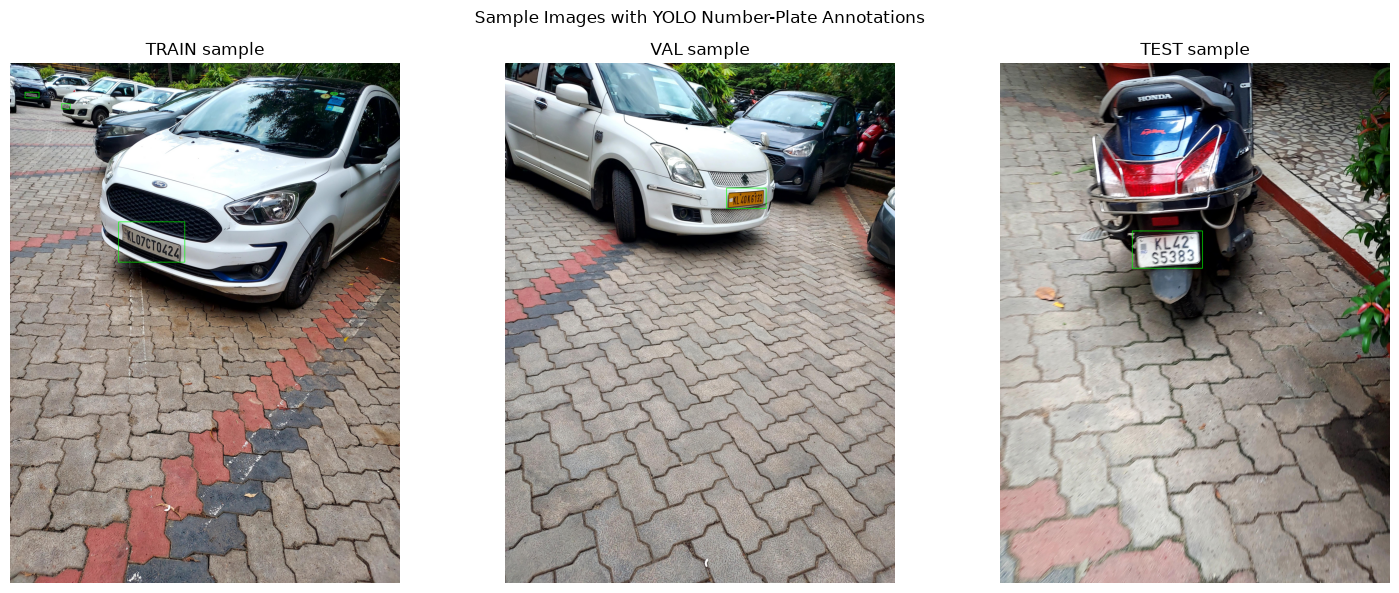

In [11]:
sample_records = []

for split in SPLITS:

    candidates = [
        r for r
        in image_records
        if r["split"] == split
    ]

    if candidates:

        sample_records.append(
            candidates[0]
        )


fig, axes = plt.subplots(
    1,
    len(sample_records),
    figsize=(15, 6)
)


for ax, rec in zip(
    axes,
    sample_records
):

    label_path = (
        DATA_DIR
        / rec["split"]
        / "labels"
        / f"{rec['stem']}.txt"
    )


    annotated = draw_yolo_boxes(
        rec["image_path"],
        label_path
    )


    ax.imshow(
        annotated
    )

    ax.set_title(
        f"{rec['split'].upper()} sample"
    )

    ax.axis("off")


plt.suptitle(
    "Sample Images with YOLO Number-Plate Annotations"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "04_annotation_examples.png",
    dpi=160
)

plt.show()

### Plot Interpretation — Annotation Samples

The annotated samples provide a visual cross-check that YOLO labels align with visible number plates in the **train, validation, and test** splits.

This is important because numeric coordinate validation alone cannot prove that a box surrounds the correct visual object.

The examples confirm that the annotation format is not only structurally valid but also visually meaningful across all three frozen partitions.

## 4. Image Quality Analysis and Dataset Refinement

Image quality can significantly affect both number-plate detection and OCR.

The following objective indicators are measured:

- image width and height;
- resolution;
- average brightness;
- image sharpness using Laplacian variance.

The automatic quality checks are used as **review indicators**, not automatic deletion rules. A slightly blurred or difficult image can still be valuable when the plate remains localizable and its annotation is valid.


### 4.1 Image Quality Metrics


In [12]:
quality_rows = []


for rec in image_records:

    image = cv2.imread(
        str(
            rec["image_path"]
        )
    )

    if image is None:

        quality_rows.append({
            "split": rec["split"],
            "image":
                rec["image_path"].name,
            "read_error": True
        })

        continue


    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    height, width = (
        gray.shape
    )


    brightness = float(
        gray.mean()
    )


    sharpness = float(
        cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()
    )


    quality_rows.append({
        "split": rec["split"],
        "image":
            rec["image_path"].name,
        "width": width,
        "height": height,
        "megapixels":
            width
            * height
            / 1_000_000,
        "brightness":
            brightness,
        "sharpness":
            sharpness,
        "read_error":
            False
    })


quality = pd.DataFrame(
    quality_rows
)


display(
    quality[
        [
            "width",
            "height",
            "megapixels",
            "brightness",
            "sharpness"
        ]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
width,115.0,3000.000000,0.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
height,115.0,4000.000000,0.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
megapixels,115.0,12.000000,0.000000,12.000000,12.000000,12.000000,12.000000,12.000000
brightness,115.0,141.718400,16.044026,106.711079,130.454434,140.191889,155.483734,175.489522
sharpness,115.0,626.338191,613.070650,25.118160,177.806464,344.333175,912.878468,2766.745909


### 4.2 Quality Review Thresholds


In [13]:
BLUR_REVIEW_THRESHOLD = 60

DARK_REVIEW_THRESHOLD = 60

BRIGHT_REVIEW_THRESHOLD = 200

LOW_RES_SIDE = 480


quality[
    "flag_blur"
] = (
    quality["sharpness"]
    < BLUR_REVIEW_THRESHOLD
)


quality[
    "flag_dark"
] = (
    quality["brightness"]
    < DARK_REVIEW_THRESHOLD
)


quality[
    "flag_overexposed"
] = (
    quality["brightness"]
    > BRIGHT_REVIEW_THRESHOLD
)


quality[
    "flag_low_resolution"
] = (
    quality[
        ["width", "height"]
    ]
    .min(axis=1)
    < LOW_RES_SIDE
)


quality[
    "review_required"
] = (
    quality[
        [
            "flag_blur",
            "flag_dark",
            "flag_overexposed",
            "flag_low_resolution"
        ]
    ]
    .any(axis=1)
)


quality_flags = (
    quality[
        [
            "flag_blur",
            "flag_dark",
            "flag_overexposed",
            "flag_low_resolution",
            "review_required"
        ]
    ]
    .sum()
    .rename("image_count")
    .to_frame()
)


display(
    quality_flags
)

,image_count
flag_blur,8
flag_dark,0
flag_overexposed,0
flag_low_resolution,0
review_required,8


### 4.3 Brightness and Sharpness Distributions


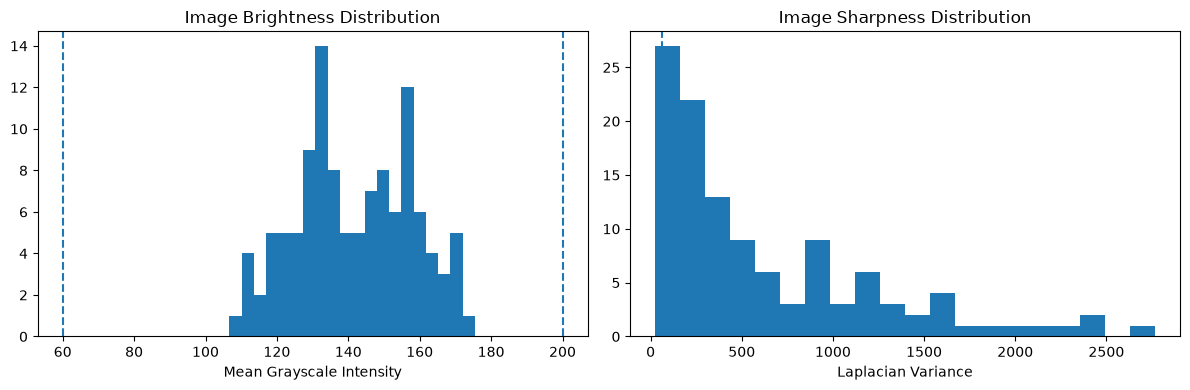

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)


axes[0].hist(
    quality[
        "brightness"
    ],
    bins=20
)

axes[0].axvline(
    DARK_REVIEW_THRESHOLD,
    linestyle="--"
)

axes[0].axvline(
    BRIGHT_REVIEW_THRESHOLD,
    linestyle="--"
)

axes[0].set_title(
    "Image Brightness Distribution"
)

axes[0].set_xlabel(
    "Mean Grayscale Intensity"
)


axes[1].hist(
    quality[
        "sharpness"
    ],
    bins=20
)

axes[1].axvline(
    BLUR_REVIEW_THRESHOLD,
    linestyle="--"
)

axes[1].set_title(
    "Image Sharpness Distribution"
)

axes[1].set_xlabel(
    "Laplacian Variance"
)


plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "05_image_quality.png",
    dpi=160
)

plt.show()

### Plot Interpretation — Image Quality

The brightness histogram is concentrated well between the dark and overexposure review thresholds, which is consistent with the later finding that all 115 images fall into the `Normal` brightness group.

The sharpness histogram is much more spread out. Most images have adequate Laplacian variance, but a small lower-tail falls below the **60** review threshold.

Exactly **8 images** are flagged for low sharpness. No image is flagged for darkness, overexposure, or low resolution.

**Key takeaway:** blur/sharpness is the main image-quality concern in this frozen dataset, rather than resolution or extreme whole-image brightness.

### 4.4 Manual Review of Low-Sharpness Images

Images below the sharpness review threshold are inspected visually with their YOLO bounding boxes. The purpose of this step is to determine whether the flagged samples are genuinely unusable or simply difficult but valid examples.


In [15]:
# ============================================================
# VISUAL REVIEW OF BLURRED / LOW-SHARPNESS IMAGES
# ============================================================

blurred_candidates = (
    quality[quality["flag_blur"]]
    .sort_values("sharpness")
    .reset_index(drop=True)
)

print("Blurred candidates:", len(blurred_candidates))

display(
    blurred_candidates[
        [
            "split",
            "image",
            "sharpness",
            "brightness"
        ]
    ]
)

Blurred candidates: 8


,split,image,sharpness,brightness
0,train,20230620_160128ll.jpg,25.118160,145.069749
1,train,20230620_155828ll.jpg,38.311688,120.224208
2,test,20230614_151246ll.jpg,38.497955,128.598864
3,train,20230614_151244ll.jpg,38.783793,136.498997
4,train,20230614_151016ll.jpg,40.006582,140.191889
5,train,20230620_160408ll.jpg,48.217162,168.857001
6,train,20230620_160022ll.jpg,51.743346,138.953749
7,train,20230620_160522ll.jpg,55.202709,146.326532


In [16]:
def show_image_with_yolo_boxes(split, image_name):

    image_path = (
        DATA_DIR
        / split
        / "images"
        / image_name
    )

    label_path = (
        DATA_DIR
        / split
        / "labels"
        / f"{Path(image_name).stem}.txt"
    )

    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read {image_path}")

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w = image.shape[:2]

    if label_path.exists():

        for line in label_path.read_text().splitlines():

            if not line.strip():
                continue

            cls, xc, yc, bw, bh = map(
                float,
                line.split()
            )

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)

            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                max(3, int(w / 900))
            )

    return image

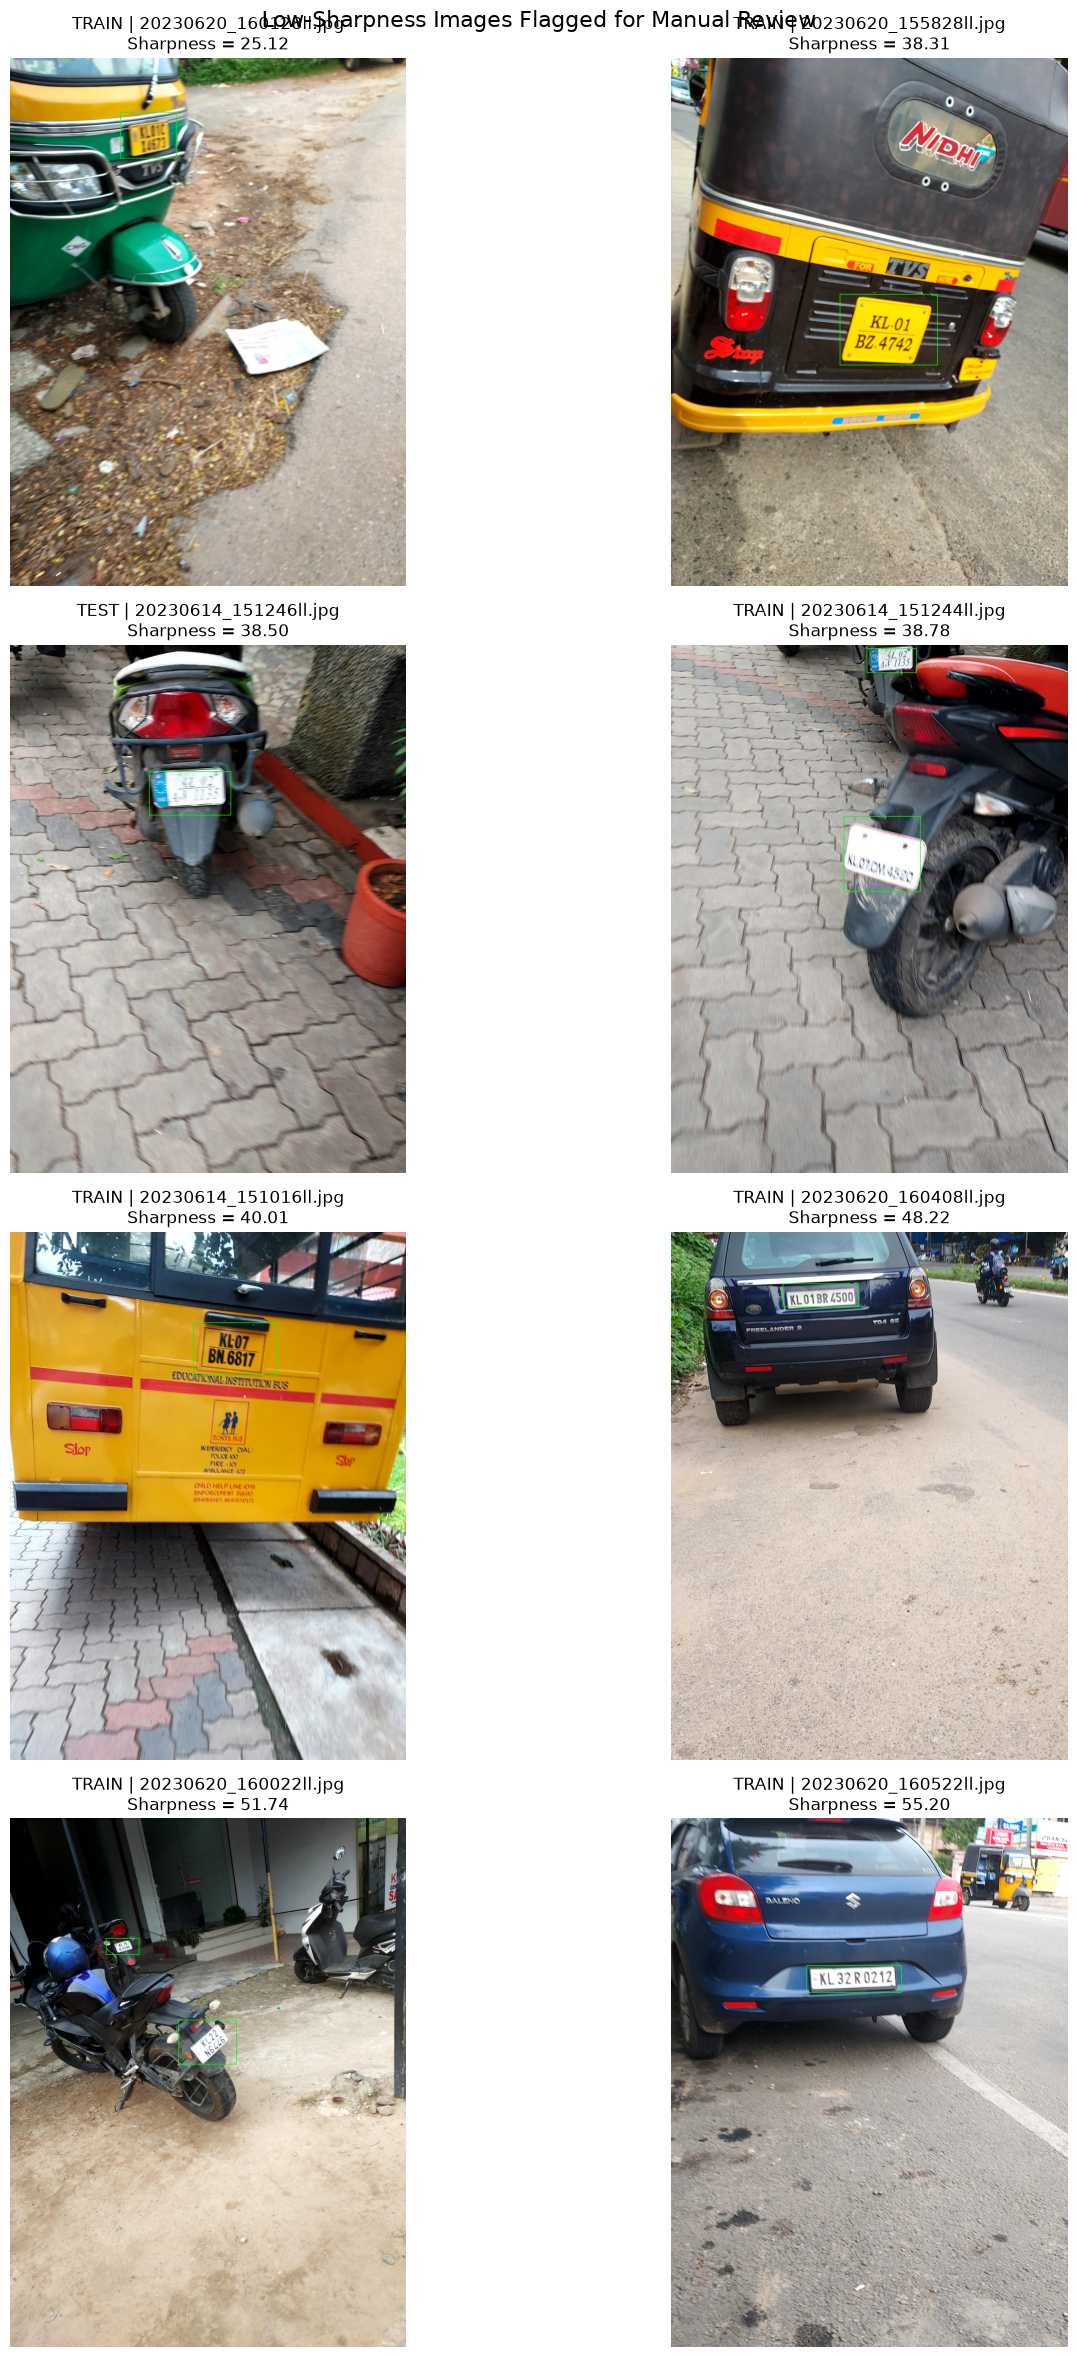

In [17]:
# ============================================================
# DISPLAY ALL BLURRED CANDIDATES
# ============================================================

n = len(blurred_candidates)

cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, 6 * rows)
)

axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(
    axes,
    blurred_candidates.iterrows()
):

    annotated = show_image_with_yolo_boxes(
        row["split"],
        row["image"]
    )

    ax.imshow(annotated)

    ax.set_title(
        f"{row['split'].upper()} | {row['image']}\n"
        f"Sharpness = {row['sharpness']:.2f}"
    )

    ax.axis("off")


# Hide empty plot areas
for ax in axes[n:]:
    ax.axis("off")


plt.suptitle(
    "Low-Sharpness Images Flagged for Manual Review",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "blurred_images_manual_review.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

### 4.5 Manual Review Decision

The low-sharpness review plot contains **8 flagged images**. Seven are from the training split and one is from the test split.

Although their Laplacian-variance sharpness scores fall below the review threshold, the number plates remain visually localizable and the YOLO boxes remain valid.

The samples are therefore retained rather than removed.

**Plot interpretation:**  
The figure demonstrates that an automated blur threshold is useful for identifying difficult cases, but it should not be treated as an automatic deletion rule. Visual inspection confirms that these are challenging-but-valid examples rather than corrupted samples.

### 4.6 Final Dataset Refinement Decision


In [18]:
flagged = quality[
    quality[
        "review_required"
    ]
].copy()


display(
    flagged[
        [
            "split",
            "image",
            "brightness",
            "sharpness",
            "flag_blur",
            "flag_dark",
            "flag_overexposed",
            "flag_low_resolution"
        ]
    ]
)


FLAGGED_COUNT = len(
    flagged
)


# --------------------------------------------------
# IMPORTANT:
# EDA DOES NOT DELETE DATA AUTOMATICALLY
# --------------------------------------------------

quality[
    "refinement_decision"
] = np.where(
    quality[
        "review_required"
    ],
    "RETAIN - difficult sample reviewed",
    "RETAIN"
)


quality[
    [
        "split",
        "image",
        "review_required",
        "refinement_decision"
    ]
].to_csv(
    REPORT_DIR
    / "dataset_refinement_decision.csv",
    index=False
)


print(
    "Images flagged for review:",
    FLAGGED_COUNT
)

print(
    "Images automatically removed:",
    0
)

print(
    "Final retained images:",
    TOTAL_IMAGES
)

,split,image,brightness,sharpness,flag_blur,flag_dark,flag_overexposed,flag_low_resolution
18,train,20230614_151016ll.jpg,140.191889,40.006582,True,False,False,False
23,train,20230614_151244ll.jpg,136.498997,38.783793,True,False,False,False
26,train,20230620_155828ll.jpg,120.224208,38.311688,True,False,False,False
29,train,20230620_160022ll.jpg,138.953749,51.743346,True,False,False,False
38,train,20230620_160128ll.jpg,145.069749,25.118160,True,False,False,False
60,train,20230620_160408ll.jpg,168.857001,48.217162,True,False,False,False
65,train,20230620_160522ll.jpg,146.326532,55.202709,True,False,False,False
104,test,20230614_151246ll.jpg,128.598864,38.497955,True,False,False,False


Images flagged for review: 8
Images automatically removed: 0
Final retained images: 115


### Dataset Refinement Result

The automated EDA flagged **8 of 115 images** for additional quality review.

The review rules are deliberately conservative. A flagged image is **not automatically removed**, because difficult images can still represent valid real-world conditions and remain useful for localization.

Final decision:

- **Images flagged for review:** 8
- **Automatically removed images:** 0
- **Additional images introduced after the frozen split:** 0
- **Final retained images:** 115

All eight flagged images were visually reviewed and retained because the number plates remained identifiable and the YOLO annotations remained valid.

**Interpretation:**  
The dataset was not artificially simplified to improve metrics. Difficult but usable images were preserved to maintain a more realistic evaluation setting.

## 5. Lighting and Environmental Variability


In [20]:
def lighting_group(
    brightness
):

    if brightness < 80:
        return "Low-light"

    elif brightness > 180:
        return "Bright"

    else:
        return "Normal"


quality[
    "lighting_group"
] = (
    quality[
        "brightness"
    ]
    .apply(
        lighting_group
    )
)


lighting_counts = (
    quality[
        "lighting_group"
    ]
    .value_counts()
    .rename_axis(
        "lighting_group"
    )
    .reset_index(
        name="images"
    )
)


display(
    lighting_counts
)

,lighting_group,images
0,Normal,115


### 5.1 Lighting Distribution


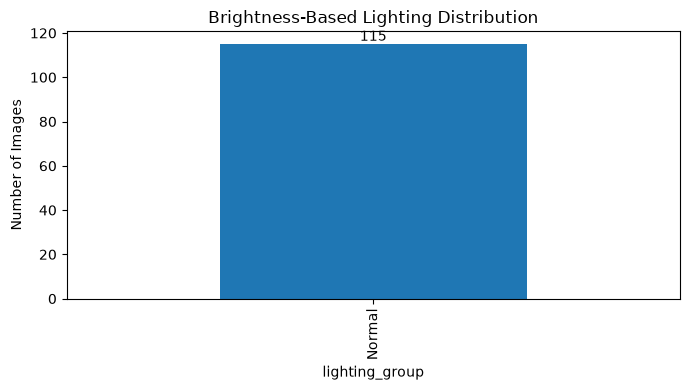

In [21]:
ax = (
    lighting_counts
    .set_index(
        "lighting_group"
    )["images"]
    .plot(
        kind="bar",
        figsize=(7, 4)
    )
)

ax.set_title(
    "Brightness-Based Lighting Distribution"
)

ax.set_ylabel(
    "Number of Images"
)

ax.bar_label(
    ax.containers[0]
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "06_lighting_distribution.png",
    dpi=160
)

plt.show()

### 5.2 Lighting Distribution Interpretation

The lighting-distribution plot places all **115 images** in the `Normal` brightness category using the notebook's current thresholds.

This does **not** mean that every image has identical lighting. The measured mean grayscale brightness still varies across images, but none crosses the selected low-light or overexposure review thresholds.

**Implication:**  
The final dataset has limited evidence for objectively measured extreme lighting conditions. Therefore, claims about poor-light robustness should come from model evaluation on suitable examples, not from this EDA plot alone.

In [22]:
# Lighting counts are already computed above.
# Display the objective brightness-group summary.
display(lighting_counts)


### Lighting and Weather Analysis Result

Brightness-based grouping produced:

- **Normal-light images:** 115
- **Low-light images:** 0
- **Bright/overexposed images:** 0

The mean whole-image brightness ranges from approximately **106.7 to 175.5**, so every image falls inside the notebook's current objective `Normal` brightness range.

Whole-image brightness can quantify illumination, but it cannot reliably infer:

- rain;
- fog;
- exact day/night category;
- clear-weather conditions;
- camera-angle category.

Those metadata are not present in the YOLO annotations.

**Interpretation:**  
The notebook reports measurable illumination characteristics without inventing unsupported environmental labels. A limitation of this dataset is that the current brightness-based audit does **not contain verified poor-light examples**, so poor-light generalization cannot be established from EDA alone.

## 6. Class Frequency Distribution


,split,number_plate_boxes
0,test,25
1,train,185
2,val,23


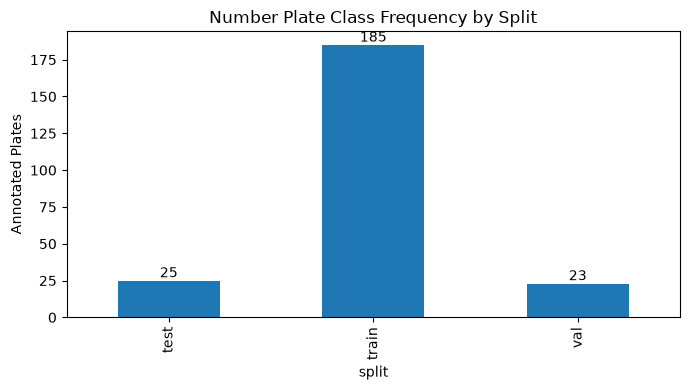

In [23]:
class_frequency = (
    boxes
    .groupby(
        "split"
    )
    .size()
    .rename(
        "number_plate_boxes"
    )
    .reset_index()
)


display(
    class_frequency
)


ax = (
    class_frequency
    .set_index(
        "split"
    )[
        "number_plate_boxes"
    ]
    .plot(
        kind="bar",
        figsize=(7, 4)
    )
)


ax.set_title(
    "Number Plate Class Frequency by Split"
)

ax.set_ylabel(
    "Annotated Plates"
)

ax.bar_label(
    ax.containers[0]
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "07_class_frequency.png",
    dpi=160
)

plt.show()

### Plot Interpretation — Class Frequency by Split

The bar heights reflect the frozen split sizes and the number of objects per image:

- training contains **185** plate boxes;
- validation contains **23**;
- test contains **25**.

The test split contains slightly more boxes than validation even though it has one fewer image, showing that image count and object count are not identical measures of split complexity.

### 6.1 Class Frequency Interpretation

This is a **single-class object-detection dataset**:

**Class 0 — `number_plate`**

The class-frequency plot shows the number of annotated plate objects in each frozen split:

- **Training:** 185 boxes
- **Validation:** 23 boxes
- **Test:** 25 boxes
- **Total:** 233 boxes

Traditional multi-class imbalance analysis is therefore not applicable.

Instead, this plot verifies that the target object is represented in every split. Regional or state-specific plate styles cannot be inferred from the YOLO class label because all plates share the same class ID.

## 7. Image Preprocessing Demonstration


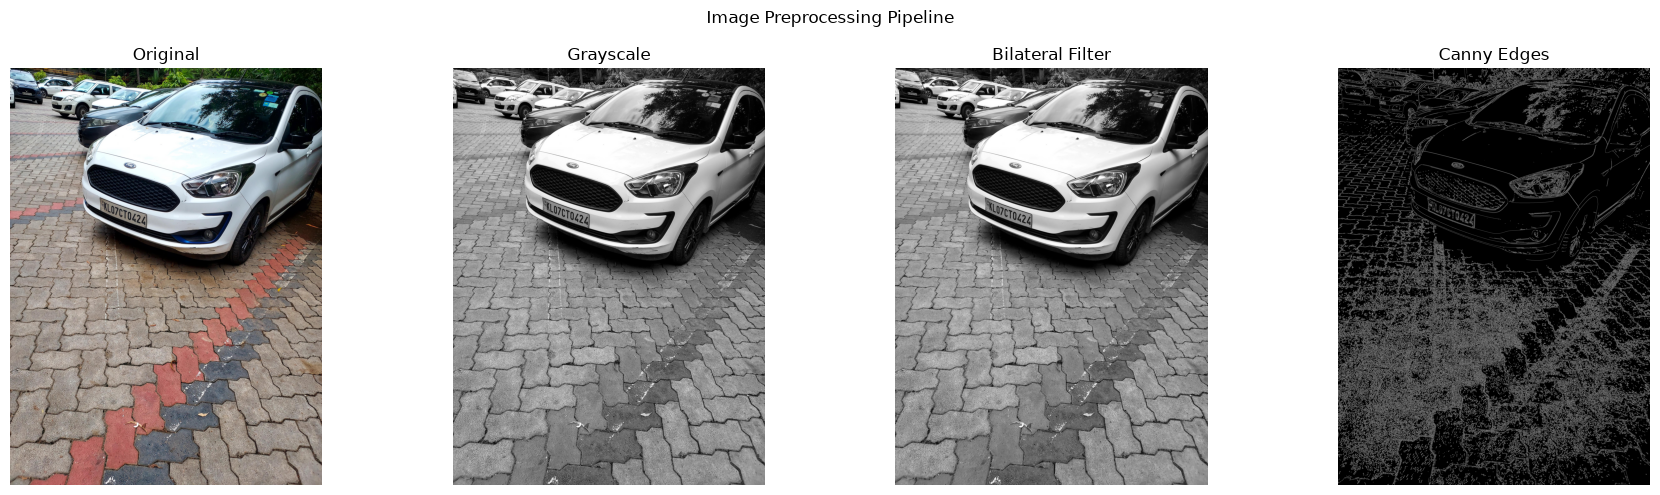

In [24]:
# Select a real training image

training_images = [
    r["image_path"]
    for r
    in image_records
    if r["split"]
    == "train"
]


sample_path = (
    training_images[0]
)


original_bgr = cv2.imread(
    str(sample_path)
)


original_rgb = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2RGB
)


gray = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2GRAY
)


bilateral = cv2.bilateralFilter(
    gray,
    11,
    17,
    17
)


canny = cv2.Canny(
    bilateral,
    30,
    200
)


fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)


axes[0].imshow(
    original_rgb
)

axes[0].set_title(
    "Original"
)


axes[1].imshow(
    gray,
    cmap="gray"
)

axes[1].set_title(
    "Grayscale"
)


axes[2].imshow(
    bilateral,
    cmap="gray"
)

axes[2].set_title(
    "Bilateral Filter"
)


axes[3].imshow(
    canny,
    cmap="gray"
)

axes[3].set_title(
    "Canny Edges"
)


for ax in axes:
    ax.axis("off")


plt.suptitle(
    "Image Preprocessing Pipeline"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "08_preprocessing_pipeline.png",
    dpi=160
)

plt.show()

### Plot Interpretation — Preprocessing Views

The original image retains the complete visual signal. Grayscale simplifies the representation, bilateral filtering reduces local noise while maintaining edges, and Canny converts the scene into an edge-focused representation.

For number plates, these transformations can make character and border structure more visually prominent, but they can also discard information. This is why preprocessing choices were evaluated rather than assumed to improve OCR automatically.

### 7.1 Preprocessing Interpretation

The preprocessing figure compares the same training image in four forms:

- **Original:** preserves the full colour information used by the detector.
- **Grayscale:** removes colour and retains luminance structure.
- **Bilateral filter:** smooths local noise while attempting to preserve strong edges.
- **Canny edges:** emphasizes high-contrast boundaries and character/plate contours.

These transformations are shown as exploratory preprocessing examples. They are **not all applied to the final YOLO detector input**.

For the final OCR pipeline, controlled OCR experiments were performed separately in the OCR notebook. The selected production OCR configuration ultimately uses the **original YOLO crop with PaddleOCR**, because that combination produced the best frozen-benchmark result.

## 8. Resizing and Normalization


In [25]:
TARGET_IMGSZ = 832


sample = cv2.imread(
    str(sample_path)
)


height, width = (
    sample.shape[:2]
)


scale = (
    TARGET_IMGSZ
    / max(
        height,
        width
    )
)


resized_width = int(
    width * scale
)

resized_height = int(
    height * scale
)


print(
    "Original resolution:",
    f"{width} × {height}"
)

print(
    "Illustrative resized resolution:",
    f"{resized_width} × {resized_height}"
)

print(
    "YOLO training image size:",
    TARGET_IMGSZ
)

Original resolution: 3000 × 4000
Illustrative resized resolution: 624 × 832
YOLO training image size: 832


### 8.1 Resizing and Normalization Interpretation

The sample source image has a resolution of **3000 × 4000 pixels**. For an illustrative aspect-ratio-preserving resize, the longer side is scaled to **832 pixels**, giving approximately **624 × 832 pixels**.

The YOLO training configuration uses an image size of **832**. Ultralytics handles the detector's resize/letterbox and tensor normalization internally during training and inference.

**Why this matters:**  
Reducing the working resolution substantially lowers computation while retaining enough spatial detail for plate detection. However, because number plates are often very small objects, excessive downscaling could remove useful detail, which is one reason the project uses 832 rather than a smaller detector input size.

## 9. Data Augmentation Demonstration


In [26]:
def rotate_image(
    img,
    degrees=7
):

    h, w = img.shape[:2]

    matrix = (
        cv2.getRotationMatrix2D(
            (w / 2, h / 2),
            degrees,
            1
        )
    )

    return cv2.warpAffine(
        img,
        matrix,
        (w, h),
        borderMode=
            cv2.BORDER_REFLECT
    )


def brightness_change(
    img,
    factor=0.65
):

    return np.clip(
        img.astype(
            np.float32
        )
        * factor,
        0,
        255
    ).astype(
        np.uint8
    )


def add_noise(
    img,
    sigma=12
):

    rng = (
        np.random
        .default_rng(42)
    )

    noise = rng.normal(
        0,
        sigma,
        img.shape
    )


    return np.clip(
        img.astype(
            np.float32
        )
        + noise,
        0,
        255
    ).astype(
        np.uint8
    )


def crop_resize(
    img,
    fraction=0.88
):

    h, w = img.shape[:2]

    new_h = int(
        h * fraction
    )

    new_w = int(
        w * fraction
    )


    y1 = (
        h - new_h
    ) // 2

    x1 = (
        w - new_w
    ) // 2


    cropped = img[
        y1:y1 + new_h,
        x1:x1 + new_w
    ]


    return cv2.resize(
        cropped,
        (w, h)
    )

### 9.1 Augmentation Examples


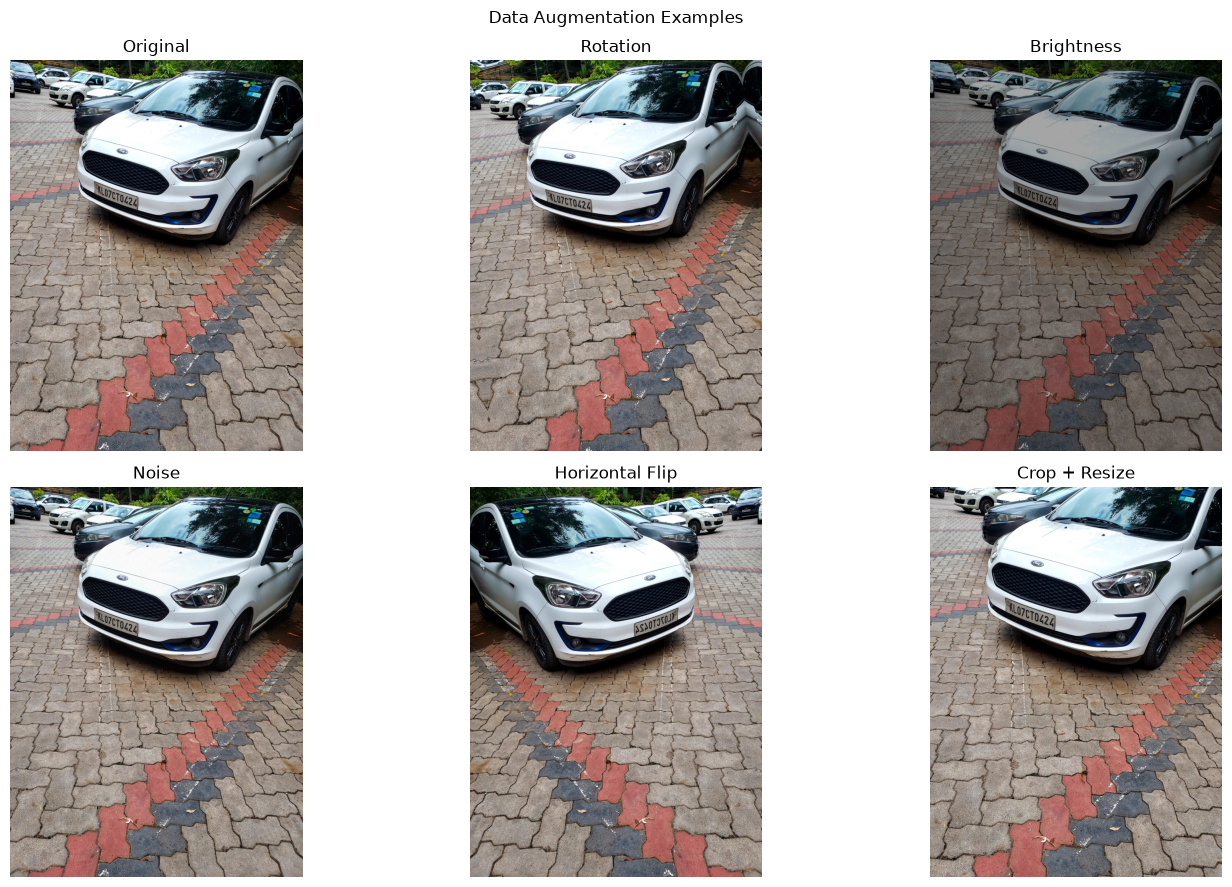

In [27]:
examples = {
    "Original":
        original_rgb,

    "Rotation":
        rotate_image(
            original_rgb
        ),

    "Brightness":
        brightness_change(
            original_rgb
        ),

    "Noise":
        add_noise(
            original_rgb
        ),

    "Horizontal Flip":
        cv2.flip(
            original_rgb,
            1
        ),

    "Crop + Resize":
        crop_resize(
            original_rgb
        )
}


fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)


for ax, (
    title,
    image
) in zip(
    axes.ravel(),
    examples.items()
):

    ax.imshow(
        image
    )

    ax.set_title(
        title
    )

    ax.axis("off")


plt.suptitle(
    "Data Augmentation Examples"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "09_augmentation_examples.png",
    dpi=160
)

plt.show()

### Plot Interpretation — Augmentation Examples

The augmentation panel shows that the same labelled scene can be presented to a model under several controlled visual variations without changing the underlying object identity.

The transformations are deliberately moderate: the plate should remain recognizable after augmentation. Unrealistically strong augmentation could distort the plate or invalidate the relationship between image content and bounding-box labels.

The examples therefore demonstrate the **type** of variability introduced, while the training notebook remains the source of truth for the actual augmentation configuration used during detector training.

### 9.2 Augmentation Strategy and Expected Effect

The augmentation figure demonstrates:

- rotation;
- brightness variation;
- image noise;
- horizontal flipping;
- cropping and resizing.

Visually, each transformation changes a different property of the same source image:

- **Rotation** simulates small camera or vehicle-angle changes.
- **Brightness variation** simulates illumination differences.
- **Noise** approximates sensor/compression degradation.
- **Horizontal flip** changes vehicle direction and scene orientation.
- **Crop + resize** changes framing and apparent object scale.

These examples illustrate the intended robustness benefits, but the figure by itself does **not prove a numerical accuracy improvement**.

A controlled augmentation experiment would require two otherwise identical training runs and comparison of Precision, Recall, mAP@50, and mAP@50-95. Therefore, no numerical augmentation gain is claimed unless supported by training results.

## 10. Save EDA Outputs


In [28]:
composition.to_csv(
    REPORT_DIR
    / "dataset_composition.csv",
    index=False
)


boxes.to_csv(
    REPORT_DIR
    / "bounding_box_audit.csv",
    index=False
)


quality.to_csv(
    REPORT_DIR
    / "image_quality_audit.csv",
    index=False
)


eda_summary = pd.DataFrame([
    {
        "metric":
            "total_images",
        "value":
            TOTAL_IMAGES
    },
    {
        "metric":
            "total_boxes",
        "value":
            TOTAL_BOXES
    },
    {
        "metric":
            "invalid_annotations",
        "value":
            INVALID_BOXES
    },
    {
        "metric":
            "quality_review_images",
        "value":
            FLAGGED_COUNT
    },
    {
        "metric":
            "images_removed_after_eda",
        "value":
            0
    },
    {
        "metric":
            "final_images_retained",
        "value":
            TOTAL_IMAGES
    },
    {
        "metric":
            "mean_brightness",
        "value":
            round(
                float(
                    quality[
                        "brightness"
                    ].mean()
                ),
                2
            )
    },
    {
        "metric":
            "median_sharpness",
        "value":
            round(
                float(
                    quality[
                        "sharpness"
                    ].median()
                ),
                2
            )
    },
    {
        "metric":
            "detection_class",
        "value":
            "number_plate"
    }
])


eda_summary.to_csv(
    REPORT_DIR
    / "eda_summary.csv",
    index=False
)


display(
    eda_summary
)


print(
    "\nEDA reports saved to:"
)

print(
    REPORT_DIR
)

,metric,value
0,total_images,115
1,total_boxes,233
2,invalid_annotations,0
3,quality_review_images,8
4,images_removed_after_eda,0
5,final_images_retained,115
6,mean_brightness,141.72
7,median_sharpness,344.33
8,detection_class,number_plate



EDA reports saved to:
C:\Users\david\OneDrive\Desktop\MT48-DS-David\GUVI DS Projects\Number-Plate-Detection-Final\reports\eda_final


# Final EDA Conclusion

The pre-training dataset audit confirms:

| Metric | Result |
|---|---:|
| Images | **115** |
| Training | **90** |
| Validation | **13** |
| Test | **12** |
| Number-plate boxes | **233** |
| Invalid YOLO annotations | **0** |
| Missing image-label pairs | **0** |
| Plates per image | **2.03 average** |
| Maximum plates/image | **7** |
| Images flagged for quality review | **8** |
| Automatically removed images | **0** |
| Final retained images | **115** |
| Detection classes | **1 — number_plate** |

## Final Dataset Decision

The dataset is considered **ready for YOLO training** because:

- all image/label pairs are valid;
- YOLO annotations pass structural validation;
- plate sizes and aspect ratios have been analysed;
- eight low-sharpness images were flagged and visually reviewed;
- the reviewed images remain usable for localization and were retained as realistic difficult samples;
- no images were removed solely to improve model metrics;
- preprocessing and augmentation methods are documented;
- train, validation and test partitions remain separated.
